In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [2]:
# --- Extended Value Class ---
# The extra operations (pow, neg, sub, div, exp, sigmoid) are PROVIDED.
# The four TODOs are the pieces YOU built in Task 2.4 — paste your implementations in.

class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __neg__(self): # -self
        return self * -1

  def __radd__(self, other): # other + self
      return self + other

  def __sub__(self, other): # self - other
      return self + (-other)

  def __rsub__(self, other): # other - self
      return other + (-self)

  def __rmul__(self, other): # other * self
      return self * other

  def __truediv__(self, other): # self / other
      return self * other**-1

  def __rtruediv__(self, other): # other / self
      return other * self**-1

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def sigmoid(self):
    x = self.data
    t = 1.0 / (1.0 + math.exp(-x))
    out = Value(t, (self, ), 'sigmoid')
    
    def _backward():
      self.grad += t * (1-t) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    
    return out
  
  ###################  
  def relu(self):
      x = self.data
      out = Value(max(0, x), (self,), "ReLU")

      def _backward():
          self.grad += (x > 0) * out.grad #slope = 1 if x > 0 else 0
      out._backward = _backward

      return out

  def log(self):
    eps = 1e-8
    x = max(self.data, eps)  #prevent 0 
    out = Value(math.log(x), (self,), 'log')

    def _backward():
        self.grad += (1 / x) * out.grad #ln(x) > 1/x
    out._backward = _backward
    return out
  
  ####################
  
  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


## Part 3: Building a Neural Network

Now that we have our `Value` object with automatic differentiation, we can build neural network components.

We will create three classes: `Neuron`, `Layer`, and `MLP` (Multi-Layer Perceptron).

*(A `Module` class is provided to help with managing parameters).*

In [3]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):
  # TASK 3.1: Complete the Neuron class.e
  def __init__(self, nin , relu = True):
    # A neuron has 'nin' weights (w) and one bias (b).
    # Initialize weights randomly between -1 and 1.
    # self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    # self.b = ...
    std = (2 / nin) ** 0.5 
    self.w = [Value(random.gauss(0, std)) for _ in range(nin)]
    self.b = Value(0) #mentioned that with He initialization, the bias is often initialized to 0

    self.relu = relu
  
  def __call__(self, x):
    # This should compute the activation of the neuron.
    # Formula: act = w[0]*x[0] + w[1]*x[1] + ... + b
    # Then pass the activation through a non-linearity like tanh.
    # act = ...
    # return act.tanh()
    zipped = zip(self.w, x)
    act = sum((wi * xi for wi, xi in zipped) , self.b) #x1w1 + x2w2 +x3w3 since it's 'row matrix' @ 'col matrix'
    return act.relu() if self.relu else act

  
  def parameters(self):
    return self.w + [self.b]

class Layer(Module):
  # TASK 3.2: Complete the Layer class.
  def __init__(self, nin, nout , relu = True):
    # A layer is a list of neurons.
    self.neurons = [Neuron(nin, relu=relu) for _ in range(nout)] #i actually thought for a single layer nin = nout always 
    pass
  
  def __call__(self, x , training = False , p = 0.2): 
    # When you call a layer, you call each neuron with the input x.
    outs = [neuron(x= x) for neuron in self.neurons]
    if training :
      # Apply dropout during training
      for i in range(len(outs)):
          if random.random() < p:
              outs[i] = Value(0)  # Drop the neuron output
          else:
              outs[i] = outs[i] * (1 / (1 - p))  # Scale the output to maintain expected value
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    # A layer's parameters are all the parameters from all its neurons.
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP(Module):
  # TASK 3.3: Complete the MLP class.
  def __init__(self, nin, nouts):
    # 'nouts' is a list of layer sizes.
    # e.g., MLP(3, [4, 4, 1]) is a network with 3 inputs, two hidden layers of 4 neurons, and one output neuron.
    sz = [nin] + nouts
    self.layers = []
    for i in range(len(nouts)):
        is_last_layer = (i == len(nouts) - 1)
        self.layers.append(Layer(sz[i], sz[i+1], relu=not is_last_layer))
    pass
  
  def __call__(self, x , training = False , p = 0.2):
    # Pass the input 'x' through all the layers sequentially.
    # TODO: Implement the forward pass through all layers.
    for layer in self.layers :
       x= layer(x= x , training= training , p= p) #feeds the input to layern , then takes it's output as input for layer n+1 'i'll assume they're arranged correctly' because i don't think there is enough info 
    return x #output layer output
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [4]:
def softmax(logits):
    exps = [l.exp() for l in logits]
    sum_exps = sum(exps)
    return [e / sum_exps for e in exps]

Value(data=3.9997171853981084)


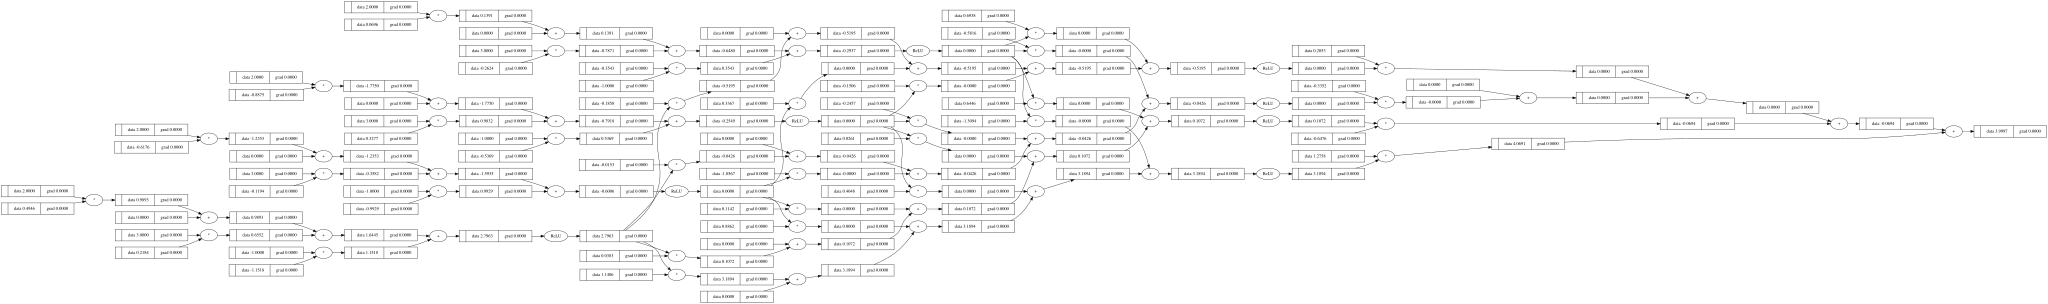

In [5]:
# --- You can test your network here ---
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
output = n(x)
print(output)
draw_dot(output)

## Part 5: Capstone Project - Handwritten Digit Recognition

It's time to put everything together and tackle a real problem: recognizing handwritten digits.

We'll use the **scikit-learn digits dataset** — a mini version of the famous MNIST benchmark. Each image is only **8×8 pixels** (64 values) instead of MNIST's 28×28 (784 values).

**Why the mini version?** Your `Value` engine processes one scalar at a time in pure Python. A single forward pass on a 28×28 image would create tens of thousands of `Value` objects — training on the full MNIST dataset would take *days*. The 8×8 version keeps the exact same problem (10-digit classification) at a size your engine can handle. In Part 6, PyTorch will let us take on the real thing.

### 5.1 Loading and Preparing the Data

*(This code is provided for you)*


In [6]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1)) # Flatten images to 64-element vectors

X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, shuffle=True, random_state=42
)

# Normalize pixel values to be between 0 and 1
X_train /= 16.0
X_test /= 16.0

# =====================================================================
# ⏱️ IMPORTANT: pure-Python training is SLOW.
# Debug your training loop on a small subset first. Once one epoch runs
# end-to-end without errors, set N_SUBSET = len(X_train) for the real run.
# =====================================================================
N_SUBSET =   1437 # <-- start small; set to 1437 (full) for your final run
X_train = X_train[:N_SUBSET]
y_train = y_train[:N_SUBSET]

# One-hot encode the labels
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

num_classes = 10
y_train_one_hot = one_hot_encode(y_train, num_classes)

print(f"Training data shape: {X_train.shape}") # 1437 samples, 64 features each
print(f"Test data shape: {X_test.shape}")   # 360 samples, 64 features each

Training data shape: (1437, 64)
Test data shape: (360, 64)


### 5.2 Building and Training the Digit Recognizer

Our network will take a 64-pixel image as input and have 10 output neurons, one for each digit (0-9).

In [7]:
# Network architecture: 64 inputs -> 32 neuron hidden layer -> 10 output neurons
# You can try changing the architecture, but this is a good starting point.
neural_network = MLP(64, [32, 10])
print(f"Number of parameters: {len(neural_network.parameters())}")

# Helper function for batching (provided)
def create_batches(X, y, batch_size):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    for start_idx in range(0, len(X), batch_size):
        end_idx = min(start_idx + batch_size, len(X))
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

Number of parameters: 2410


> ⏱️ **Heads-up on runtime:** with the full training set (1,437 samples), each epoch takes roughly **1–3 minutes** on a typical laptop — that is normal, your code is not broken. This slowness is exactly the pain point that motivates Part 6. Debug on the small `N_SUBSET` first.
>
> 🎯 **Heads-up on accuracy:** with plain **MSE loss + tanh**, expect a test accuracy of roughly **45–65%** after 10 epochs. That is the expected ceiling of this setup, not a bug in your code — MSE is simply a poor fit for 10-class classification (think about why: 9 of the 10 targets are always 0...). Don't burn hours chasing higher numbers here. The **Cross-Entropy bonus challenge** is what unlocks 90%+, and you'll see the difference immediately if you attempt it.


In [8]:
# TASK 5.1: Complete the training loop for the digit recognizer.
velocity = [0.0 for _ in neural_network.parameters()]
beta = 0.9 
lr = 0.4
batch_size = 32
n_epochs = 10

loss_history = []  # we'll record the average loss each epoch and plot it below

for epoch in range(n_epochs):
    epoch_loss = 0
    
    for X_batch, y_batch in create_batches(X_train, y_train_one_hot, batch_size):
        
        # 1. Forward Pass
        # TODO: Get predictions for each sample in the batch
        # Note: The network expects inputs as lists of Value objects
        inputs = [list(map(Value, xrow)) for xrow in X_batch]
        ypred_batch = [neural_network(x , training= True) for x in inputs]


        #
        probabilities_batch = [softmax(logits) for logits in ypred_batch]  

        # 2. Compute Loss for the batch
        # TODO: Calculate the MSE loss for the batch
        # The true labels `y_batch` also need to be converted to Value objects for the subtraction
        # 2. Cross-Entropy Loss
        loss = -sum(yt * p.log()
                    for probs, ytrue in zip(probabilities_batch, y_batch)
                    for p, yt in zip(probs, ytrue)) / len(y_batch)
                
        # 3. Backward Pass
        # TODO: Zero gradients and backpropagate
        neural_network.zero_grad()
        loss.backward()
        
        # 4. Update Parameters
        # TODO: Update weights and biases
        for i, p in enumerate(neural_network.parameters()):
            velocity[i] = beta * velocity[i] + p.grad
            p.data -= lr * velocity[i]
        
        epoch_loss += loss.data

    avg_loss = epoch_loss / (len(X_train)/batch_size)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1}, Average Loss: {avg_loss:.4f}")
    # Decrease learning rate over time
    lr *= 0.9

Epoch 1, Average Loss: 1.6943
Epoch 2, Average Loss: 1.3704
Epoch 3, Average Loss: 1.3160
Epoch 4, Average Loss: 1.1813
Epoch 5, Average Loss: 1.1787
Epoch 6, Average Loss: 1.1441
Epoch 7, Average Loss: 1.0765
Epoch 8, Average Loss: 1.0496
Epoch 9, Average Loss: 1.0773
Epoch 10, Average Loss: 1.0760


### 5.2.1 Inspecting the Training Dynamics (Required)

Never trust a model you haven't watched train. The loss curve is your first diagnostic tool: a healthy run decreases smoothly; a flat curve means it isn't learning; a spiky or exploding curve usually means the learning rate is too high.

*(Plotting code is provided — just run it.)*


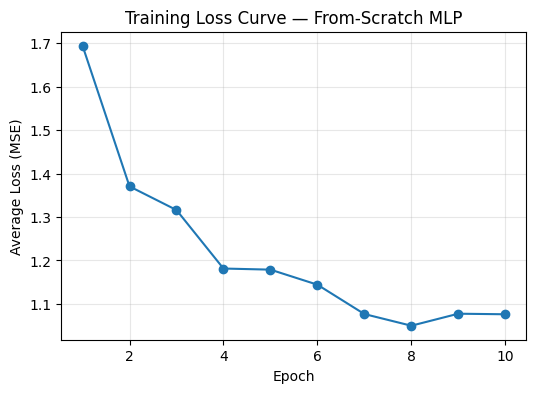

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss (MSE)")
plt.title("Training Loss Curve — From-Scratch MLP")
plt.grid(True, alpha=0.3)
plt.show()

#as it didn't platue in the end , then increasing the n of epochs would help , i wanna try with more than 10 epochs

### 5.3 Evaluating the Network

Let's see how well our trained model performs on the test set!

*(Evaluation code is provided for you)*

In [10]:
def evaluate_model(model, X_test, y_test):
    correct = 0
    total = len(X_test)
    
    inputs = [list(map(Value, xrow)) for xrow in X_test]
    
    for i in range(total):
        # Get prediction from the network
        outputs = model(inputs[i] ,training = False)
        predicted_class = np.argmax([p.data for p in outputs])
        
        if predicted_class == y_test[i]:
            correct += 1
    
    accuracy = correct / total
    print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

evaluate_model(neural_network, X_test, y_test)


Test Accuracy: 73.89%


### 5.3.1 Where Does It Go Wrong? The Confusion Matrix (Required)

Accuracy is a single number — it hides *which* digits the model confuses. The confusion matrix shows exactly that: rows are the true digits, columns are the predictions. A perfect model has everything on the diagonal.

*(Code is provided — just run it. Look at the off-diagonal cells: which pairs of digits does your model mix up?)*


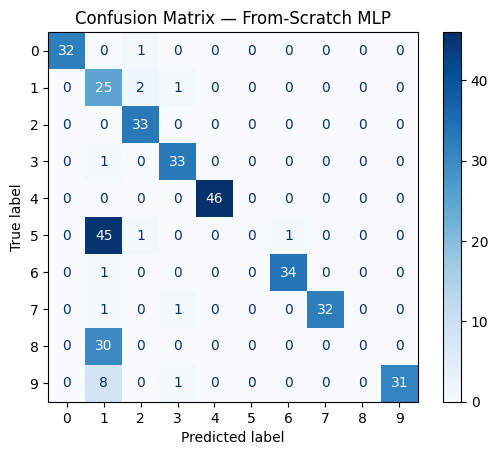

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, X):
    preds = []
    for xrow in X:
        outputs = model(list(map(Value, xrow)) , training = False)
        preds.append(np.argmax([p.data for p in outputs]))
    return np.array(preds)

y_pred_scratch = get_predictions(neural_network, X_test)

cm = confusion_matrix(y_test, y_pred_scratch)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — From-Scratch MLP")
plt.show()
#it mixes up 3 and 9 , and it detects 9 wrong most times failing to mainly 8,4 and 1



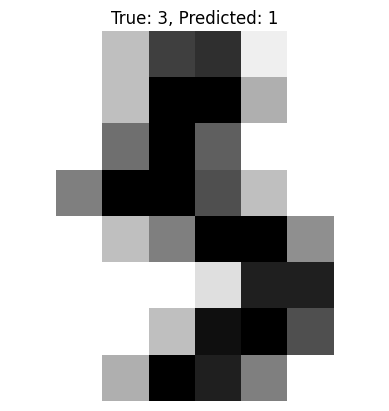

In [12]:
def show_sample_with_output(model, X_test, y_test, sample_index):
    sample = X_test[sample_index]
    true_class = y_test[sample_index]
    
    input_value = list(map(Value, sample))
    outputs = model(input_value , training = False)
    predicted_class = np.argmax([p.data for p in outputs])

    plt.imshow(sample.reshape(8, 8), cmap=plt.cm.gray_r)
    plt.title(f"True: {true_class}, Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

# Show a random sample from the test set
show_sample_with_output(neural_network, X_test, y_test, sample_index=random.randint(0, X_test.shape[0]-1))

### ✍️ Understanding Check 2 (Required)

1. Why did we **one-hot encode** the labels for training, instead of just using the digit (e.g. `7`) as the target for a single output neuron?
2. Look at your confusion matrix: pick one pair of digits your model confuses and give a plausible reason **based on how those digits look at 8×8 resolution**.
3. Roughly how long did one epoch take? Keep that number in mind — you'll compare it against PyTorch in Part 6.


*Your answers here:*

1. i know that for classification problems that's always the case to be able to use things like Softmax (entropy loss) which works better. b
ut specifically for this example if we used the target as 9 , getting 4  would be more acceptable than getting 2 or 3 since they're mode "different" visually but the errors wouldn't explain that . (the digital labels are now categories not quantities)
by using multiple output neurons each of the 10 output neurons independently learns a simple "is it this class or not" signal, and every class is equally distant from every other in target-space


2. 9 and 5 , i guess it's because both have similar curved lower part or because when people write fast they tend to almost close the curved part of the 5 and also not closing the 9 upper curve completely  , so it looks like a 9 flipped 
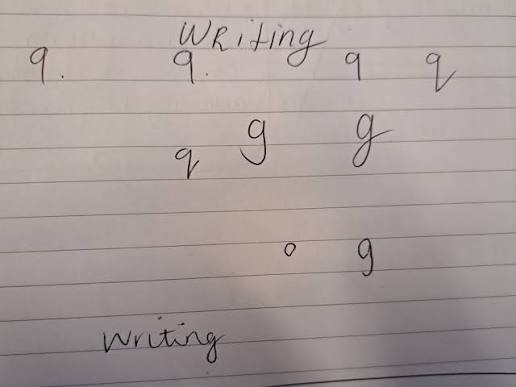

3. 2.3 minutes per epoch [whole set]


## Part 6: Putting It All Together with PyTorch

You've done the hard work. You've built an entire automatic differentiation engine and neural network library from scratch. Now, let's see how modern deep learning frameworks like **PyTorch** allow us to do the same thing with much less code — and much more speed.

To prove the point, we're upgrading the challenge: instead of the mini 8×8 digits, you will now tackle the **real MNIST dataset** — 70,000 handwritten digits at 28×28 pixels (784 inputs per image). This is the dataset your scratch engine could never handle in reasonable time; PyTorch will chew through it in seconds per epoch. You will notice many parallels to the `Module`, `Layer`, and `Value` objects you created.

First, you'll need to install PyTorch if you haven't already:


In [13]:
%pip install torch torchvision


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 6.1 Data Preparation with PyTorch

PyTorch has its own data structures for handling data and creating batches efficiently. For standard benchmarks like MNIST, the companion library **torchvision** can download the dataset and convert the images to `Tensors` for you — this `Dataset` + `DataLoader` pattern is the standard workflow you'll see in every real PyTorch project.


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# TASK 6.1: Load the real MNIST dataset and create DataLoaders.

# 1. Define the transform: convert each PIL image to a Tensor.
#    transforms.ToTensor() converts the image to a FloatTensor and scales
#    pixel values to [0, 1] — the same normalization we did manually in Part 5!
transform = transforms.ToTensor()

# 2. Download the training and test sets.
#    Use datasets.MNIST(root='./data', train=..., download=True, transform=transform)
train_dataset = datasets.MNIST(root= './data' , train = True , download= True , transform= transform) 
test_dataset  = datasets.MNIST(root= './data' , train = False , download= True , transform= transform) 

# 3. Create DataLoaders to handle batching and shuffling automatically.
#    Use DataLoader(dataset, batch_size=..., shuffle=...)
#    Shuffle the training data; the test data doesn't need shuffling.
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Let's check a batch to see what the DataLoader gives us
data_batch, labels_batch = next(iter(train_loader))
print(f"Data batch shape: {data_batch.shape}")    # Expected: [64, 1, 28, 28]
print(f"Labels batch shape: {labels_batch.shape}") # Expected: [64]
print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Data batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
Training samples: 60000, Test samples: 10000


### 6.2 Building the Model in PyTorch

In PyTorch, models are created by creating a class that inherits from `nn.Module`. This is the direct equivalent of the `Module` class you built. Layers like `nn.Linear` are PyTorch's version of your `Layer` class, with weights and biases built-in.

One new detail: MNIST images arrive as `[batch, 1, 28, 28]` tensors, but a linear layer expects a flat vector — so the first step is `nn.Flatten()`, which turns each image into a 784-element vector (just like we flattened the 8×8 images into 64 values in Part 5).


In [15]:
# TASK 6.2: Define the neural network architecture using nn.Module.

class MLP_PyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the layers of the network. Our network has:
        # 1. A Flatten layer to turn [1, 28, 28] images into 784-element vectors.
        # 2. A linear layer from 784 inputs to 128 outputs.
        # 3. A ReLU activation function.
        # 4. A final linear layer from 128 inputs to 10 outputs (for the 10 digits).
        # You can try changing the architecture, but this is a good starting point.
        # TODO: Define the layers as class attributes (e.g., self.flatten = nn.Flatten())
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(784, 128)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        # This function defines the forward pass, just like your __call__ method.
        # TODO: Pass the input 'x' through the layers you defined in __init__
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

# Instantiate the model
model = MLP_PyTorch()
print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")
# Compare that parameter count to your scratch model's ~2,400. Same code pattern, 40x the size, no sweat.


MLP_PyTorch(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)
Number of parameters: 101770


### 6.3 Defining the Loss and Optimizer

PyTorch provides standard loss functions and optimizers. For this multi-class classification problem, `CrossEntropyLoss` is the best choice (it conveniently includes the Softmax layer for you). We'll use the Adam optimizer, which is a popular and effective choice.

In [16]:
# TASK 6.3: Instantiate the loss function and optimizer.

# 1. The loss function for multi-class classification.
criterion = nn.CrossEntropyLoss()

# 2. The optimizer that will update our model's parameters.
#    It needs to know which parameters to optimize (model.parameters()).
learning_rate = 0.001
optimizer = optim.AdamW(params= model.parameters() , lr = learning_rate) # TODO: Use optim.AdamW() and pass it the model's parameters and the learning rate.

### 6.4 The Training Loop in PyTorch

The training loop in PyTorch follows a standard, clean pattern. Compare this to the loop you wrote from scratch!

In [17]:
# TASK 6.4: Complete the PyTorch training loop.

n_epochs = 12
loss_history_pt = []  # track the loss so we can plot it, same as in Part 5

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        # The standard 5-step PyTorch training process:

        # 1. Zero the gradients from the previous iteration.
        optimizer.zero_grad()
        
        # 2. Perform the forward pass to get model predictions.
        outputs = model.forward(X_batch) # TODO

        # 3. Calculate the loss.
        loss = criterion(outputs , y_batch) # TODO

        # 4. Perform the backward pass to compute gradients.
        loss.backward() # TODO
        
        # 5. Update the model's weights.
        optimizer.step() # TODO

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history_pt.append(avg_loss)
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {avg_loss:.4f}")

print("Training finished!")
# wow the loss is initially much lower even then after 20 epochs without pytorch and optimizer  and converges faster due to momentum

Epoch 1/12, Loss: 0.3509
Epoch 2/12, Loss: 0.1611
Epoch 3/12, Loss: 0.1118
Epoch 4/12, Loss: 0.0848
Epoch 5/12, Loss: 0.0665
Epoch 6/12, Loss: 0.0542
Epoch 7/12, Loss: 0.0446
Epoch 8/12, Loss: 0.0367
Epoch 9/12, Loss: 0.0310
Epoch 10/12, Loss: 0.0256
Epoch 11/12, Loss: 0.0223
Epoch 12/12, Loss: 0.0180
Training finished!


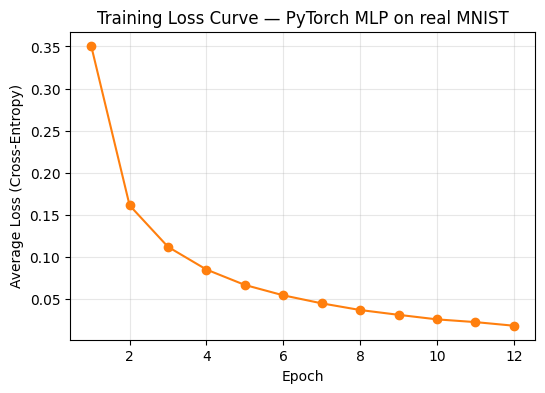

In [18]:
# Loss curve for the PyTorch model (provided)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(loss_history_pt) + 1), loss_history_pt, marker='o', color='tab:orange')
plt.xlabel("Epoch")
plt.ylabel("Average Loss (Cross-Entropy)")
plt.title("Training Loss Curve — PyTorch MLP on real MNIST")
plt.grid(True, alpha=0.3)
plt.show()


### 6.5 Evaluating the PyTorch Model

Finally, let's see how our new model performs on the test set. The evaluation loop is similar, but we tell PyTorch not to calculate gradients to save time and memory.

*(This code is provided for you)*

In [19]:
# Set the model to evaluation mode
model.eval()

correct = 0
total = 0

# Tell PyTorch not to track gradients during evaluation
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Get predictions
        outputs = model(X_batch)
        
        # The class with the highest value is our prediction
        _, predicted = torch.max(outputs.data, 1)
        
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'\nAccuracy of the network on the test images: {accuracy:.2f} %') #let's try at 20 epochs to be a fair comparison , it's currently 97.2% if it decreases it most likely overfitted 


Accuracy of the network on the test images: 97.66 %


### 6.6 Confusion Matrix & Final Comparison

*(Code is provided — just run it.)*


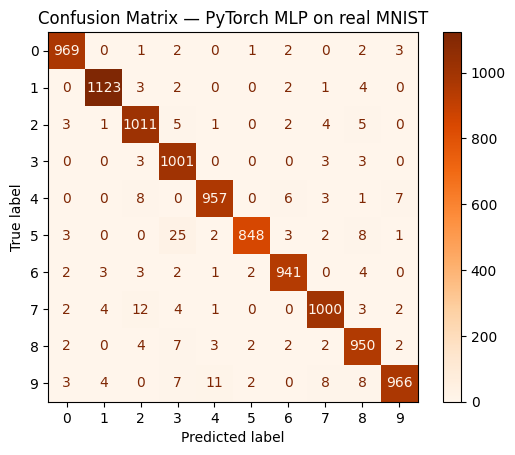

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.tolist())
        all_labels.extend(y_batch.tolist())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix — PyTorch MLP on real MNIST")
plt.show()


### ✍️ Understanding Check 3 (Required)

This is the most important reflection of the whole task. Answer in your own words:

1. Fill in this comparison table with your actual results:

| | From-scratch (8×8 digits) | PyTorch (real MNIST) |
|---|---|---|
| Dataset size (train) | 1437 | 60000 |
| Inputs per image | 64 | 784 |
| Number of parameters | 2410 |101770 |
| Time per epoch (approx.) |140 | 3.75 | S
| Test accuracy | 93.33 | 97.6 |

2. Your scratch engine and PyTorch do *conceptually the same thing*. Map the correspondence: what in your `Value` engine plays the role of `loss.backward()`? Of `optimizer.zero_grad()`? Of `optimizer.step()`?
3. Given that they do the same thing conceptually, **why** is PyTorch orders of magnitude faster? (Hint: think about scalars vs. tensors, and Python loops vs. optimized C/CUDA kernels.)


*Your answers here:*

1. (fill the table above)

2. Value.backward() , Module.zero_grad() , the parameters updating loop 

3. i know that it converges way faster due to the momentum provided by AdamW , Tensors are stored in contiguous memory blocks(one of the things that make C++ much faster)  
tensors also take less size than python's objects because it's raw data only with start and end points , rather than python where each element in the list is  an object with metadata , reference count and type information.
since you don't pause to find where your data is , you fetch it directly that makes it significantly faster and parallelizeable 

- [https://medium.com/@valentinradovich/why-tensors-perform-insanely-faster-than-lists-an-introduction-to-storage-bf36723bbaf2]


## Bonus Challenges & Further Exploration

Congratulations on building and training a neural network from scratch! If you're ready for more, here are some challenges to improve your model and deepen your understanding of deep learning concepts.

For each of these, you will need to modify your existing classes (`Value`, `Neuron`, `MLP`) or the training loop.

### 1. Implement a Better Loss Function: Cross-Entropy

For classification tasks, Mean Squared Error (MSE) isn't ideal. The standard and more effective loss function is **Cross-Entropy Loss**.

*   **Why?** It's designed to measure the difference between two probability distributions (your model's predictions and the one-hot encoded true labels). It generally leads to faster and more stable training for classifiers.
*   **Your Task:**
    1.  **Softmax Layer:** Before calculating the loss, the raw outputs of your network (called "logits") need to be converted into probabilities. You'll need to implement a **Softmax function** at the end of your network.
        *   *Hint:* The formula is `softmax(z_i) = exp(z_i) / sum(exp(z_j) for all j)`. You already have `exp()` in your `Value` class!
    2.  **Logarithm in `Value`:** The Cross-Entropy formula involves the natural logarithm. Add a `.log()` method to your `Value` class. Don't forget to implement its `_backward` function!
    3.  **Cross-Entropy Formula:** Implement the loss function.
        *   *Hint:* The formula is `Loss = -sum(y_true * log(y_pred))`, where `y_true` is the true label (e.g., 1) and `y_pred` is the predicted probability from the Softmax layer.
    4.  Update your training loop to use the new loss. You should see a significant improvement in training stability and final accuracy!

### 2. Use a Better Activation Function: ReLU

`tanh` and `sigmoid` can suffer from the "vanishing gradients" problem in deeper networks. The most common activation function used today is the **Rectified Linear Unit (ReLU)**.

*   **Why?** It's computationally very simple and helps mitigate vanishing gradients, often allowing networks to train faster.
*   **Your Task:**
    1.  Add a `.relu()` method to the `Value` class.
        *   *Hint:* The formula is `relu(x) = max(0, x)`.
        *   *Hint for the gradient:* The derivative is `0` if `x < 0` and `1` if `x > 0`. In your `_backward` function, you can simply check if the original data was positive to decide whether to propagate the gradient.
    2.  Modify your `Neuron` class to use `relu()` for the hidden layers. It's common to still use an appropriate function like Softmax for the final output layer in a classifier.

### 3. Implement Smarter Weight Initialization

Initializing weights from `random.uniform(-1, 1)` can be problematic. If weights are too large or too small, training can become unstable. **Principled initialization** methods solve this.

*   **Why?** Methods like Kaiming initialization set the scale of the initial weights based on the number of input and output neurons in a layer, helping gradients flow more smoothly.
*   **Your Task:**
    *   Modify the `__init__` method of your `Neuron` or `Layer` class.
    *   Instead of a fixed range, calculate the initialization range dynamically.

### 4. Improve the Optimizer: Add Momentum

Standard gradient descent can be slow and get stuck. **Momentum** is a technique that helps the optimizer accelerate in the right direction and overcome small local minima.

*   **Why?** It acts like a ball rolling down a hill, accumulating momentum and moving faster than an object that just considers the slope at its current position.
*   **Your Task:**
    1.  This change happens in your training loop's update step.
    2.  For each parameter `p` in your network, you need to keep track of its "velocity," which is a moving average of its past gradients.
    3.  *Hint:* Before the training loop, create a "velocity" dictionary or list that corresponds to your model's parameters, initialized to all zeros.
    4.  The update rule becomes a two-step process:
        *   `velocity = beta * velocity + p.grad` (where `beta` is a hyperparameter, e.g., 0.9)
        *   `p.data -= learning_rate * velocity`

### 5. Add Regularization to Prevent Overfitting: Dropout

If a network is too powerful, it can "memorize" the training data and fail to generalize to new, unseen data (overfitting). **Dropout** is a simple yet powerful technique to combat this.

*   **Why?** It forces the network to learn more robust features by preventing neurons from co-adapting too much.
*   **Your Task:**
    1.  Modify the `__call__` method of your `Layer` class.
    2.  During training, for each neuron's output in the layer, randomly set it to `0` with some probability `p` (e.g., `p=0.2`).
    3.  **Crucial Step (Inverted Dropout):** To ensure the overall magnitude of the layer's output remains the same, you must scale the outputs of the neurons that were *not* dropped out by `1 / (1 - p)`.
    4.  Add a mechanism to turn dropout **OFF** during evaluation/testing. The model should use all its neurons when making final predictions. You could pass a `training=True` flag to the `__call__` method.

